In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# 1)

In [3]:
df = pd.read_csv('Fish.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 159 entries, 0 to 158
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Species  159 non-null    object 
 1   Weight   159 non-null    float64
 2   Length1  159 non-null    float64
 3   Length2  159 non-null    float64
 4   Length3  159 non-null    float64
 5   Height   159 non-null    float64
 6   Width    159 non-null    float64
dtypes: float64(6), object(1)
memory usage: 8.8+ KB


In [5]:
df

,Species,Weight,Length1,Length2,Length3,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340
...,...,...,...,...,...,...,...
154,Smelt,12.2,11.5,12.2,13.4,2.0904,1.3936
155,Smelt,13.4,11.7,12.4,13.5,2.4300,1.2690
156,Smelt,12.2,12.1,13.0,13.8,2.2770,1.2558
157,Smelt,19.7,13.2,14.3,15.2,2.8728,2.0672


In [6]:
df_Perch = df[df['Species']=='Perch']


In [7]:
df_Perch

,Species,Weight,Length1,Length2,Length3,Height,Width
72,Perch,5.9,7.5,8.4,8.8,2.1120,1.4080
73,Perch,32.0,12.5,13.7,14.7,3.5280,1.9992
74,Perch,40.0,13.8,15.0,16.0,3.8240,2.4320
75,Perch,51.5,15.0,16.2,17.2,4.5924,2.6316
76,Perch,70.0,15.7,17.4,18.5,4.5880,2.9415
77,Perch,100.0,16.2,18.0,19.2,5.2224,3.3216
78,Perch,78.0,16.8,18.7,19.4,5.1992,3.1234
79,Perch,80.0,17.2,19.0,20.2,5.6358,3.0502
80,Perch,85.0,17.8,19.6,20.8,5.1376,3.0368
81,Perch,85.0,18.2,20.0,21.0,5.0820,2.7720


# 2)

### a) Y - Weight, X - Width

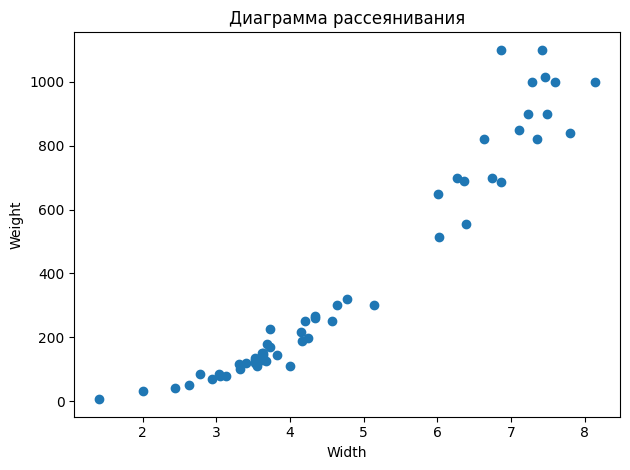

In [8]:
plt.scatter( df_Perch['Width'],df_Perch['Weight'])
plt.xlabel('Width')
plt.ylabel('Weight')
plt.title('Диаграмма рассеянивания')
plt.tight_layout()
plt.show()

### b)

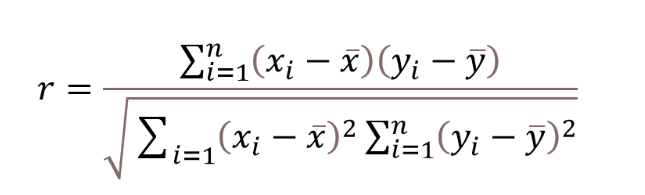

In [9]:
def corr_X_Y(X,Y):
    X_val = X.values
    Y_val = Y.values

    avg_X = np.mean(X_val)
    avg_Y = np.mean(Y_val)

    X_2 = (avg_X - X_val)**2
    Y_2 = (avg_Y - Y_val)**2

    sum_X_2 = X_2.sum()
    sum_Y_2 = Y_2.sum()

    mul_avg_X_Y = ((avg_X-X_val)*(avg_Y - Y_val)).sum()

    rXY = (mul_avg_X_Y)/np.sqrt(sum_X_2*sum_Y_2)

    return rXY






In [10]:
rxy = corr_X_Y(df_Perch['Width'],df_Perch['Weight'])
rxy

np.float64(0.9639433246031044)

### c)

In [11]:
def linear_regression(X,y):
    w1 = np.sum((y-np.mean(y))*(X-np.mean(X)))/np.sum((X-np.mean(X))**2)
    w0 = np.mean(y) - np.mean(X)*w1

    return w0+w1*X , w0, w1
 

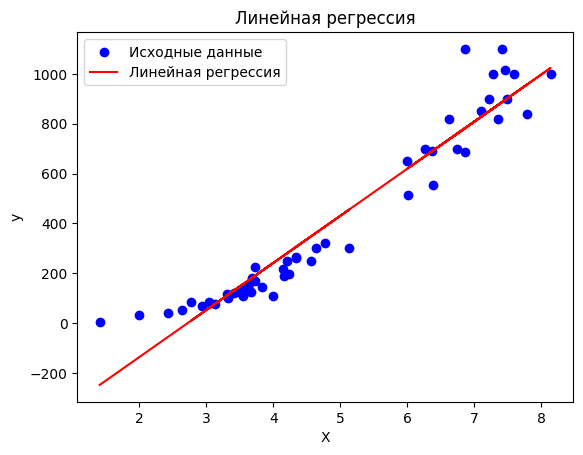

w0: -513.845118458206, w1: 188.81935665254824


In [12]:
X = df_Perch['Width'].values
y = df_Perch['Weight'].values

new_y , w0,w1= linear_regression(X, y)

plt.scatter(X, y, color='blue', label='Исходные данные')
plt.plot(X, new_y, color='red', label='Линейная регрессия')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Линейная регрессия')
plt.legend()
plt.show()

print(f'w0: {w0}, w1: {w1}')

### d)

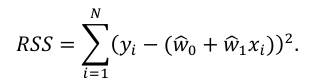

In [13]:
RSS = np.sum((y - (w0+w1*X))**2)
RSS

np.float64(470631.64657371293)

### e)

In [14]:
TSS = np.sum((y -np.mean(y))**2)
R2 = 1 - RSS/TSS
R2

np.float64(0.9291867330468856)

### 3)

### a)

In [15]:
def linear_regression_N2(X1,X2, y, learning_rate = 0.0001, epochs = 10000):

  w0 = np.random.uniform(-400,400)
  w1 = np.random.uniform(-400,400)
  w2 = np.random.uniform(-400,400)

  for _ in range(epochs):
    y_predict = w0 + w1*X1 + w2*X2
    
    dw0 = -2*np.sum(y-y_predict)
    dw1 = -2*np.sum((y-y_predict)*X1)
    dw2 = -2*np.sum((y-y_predict)*X2)

    w0 -=learning_rate*dw0
    w1 -=learning_rate*dw1
    w2 -=learning_rate*dw2

  f = w0 + w1*X1 + w2*X2

  return w0, w1, w2, f

In [85]:
X1 = df_Perch['Width'].values
X2 = df_Perch['Height'].values
y = df_Perch['Weight'].values

w0, w1, w2, f = linear_regression_N2(X1,X2,y)



print(f'w0: {w0}, w1: {w1}, w2: {w2}')

w0: -535.9988296555266, w1: 69.62174619467157, w2: 74.7700906681167


### b)

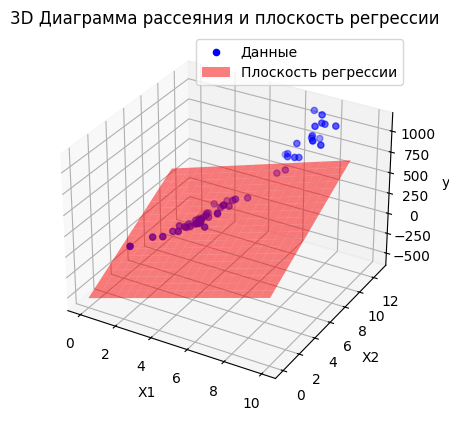

In [86]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

ax.scatter(X1, X2, y, color='blue', label='Данные')

X1_grid, X2_grid = np.meshgrid(np.linspace(0, 10, 20), np.linspace(0, 10, 20))
y_grid = w0 + w1 * X1_grid + w2 * X2_grid
ax.plot_surface(X1_grid, X2_grid, y_grid, alpha=0.5, color='red', label='Плоскость регрессии')

ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('y')
ax.set_title('3D Диаграмма рассеяния и плоскость регрессии')

plt.legend()
plt.show()

### c)

In [87]:
RSS = np.sum((y - (w0+w1*X1+w2*X2))**2)
print(RSS)

384478.1114108921


### d)

In [88]:
TSS = np.sum((y -np.mean(y))**2)
R2 = 1 - RSS/TSS
print(R2)

0.9421497654499431


### e)

In [347]:
def linear_regression_N(X1,X2=None,X3=None,X4=None,X5=None,
                        y=None,
                        learning_rate = 0.1, epochs = 100):

  w0 = np.random.uniform(-400,0)
  w1 = np.random.uniform(0,100)

  if X2 is not None:
    w2 = np.random.uniform(0,100)
  else:
    w2 = 0
    X2 = 0

  if X3 is not  None:
    w3 = np.random.uniform(-100,100)
  else:
    w3 = 0
    X3 = 0

  if X4 is not  None:
    w4 = np.random.uniform(-50,50)
  else:
    w4 = 0
    X4 = 0

  if X5 is not  None:
    w5 = np.random.uniform(-200,-30)
  else:
    w5 = 0
    X5 = 0

  for _ in range(epochs):
    
    y_predict = w0 + w1*X1 + w2*X2+ w3*X3 + w4*X4+ w5*X5
    
    dw0 = -2*np.sum(y-y_predict)
    dw1 = -2*np.sum((y-y_predict)*X1)

    if w2 != 0: 
      dw2 = -2*np.sum((y-y_predict)*X2)
      w2 -=learning_rate*dw2
    else:
      w2 =0

    if w3 !=0:
      dw3 = -2*np.sum((y-y_predict)*X3)
      w3 -=learning_rate*dw3
    else:
      w3 =0
    
    if w4 !=0:
      dw4 = -2*np.sum((y-y_predict)*X4)
      w4 -=learning_rate*dw4
    else:
      w4 =0

    if w5 != 0:
      dw5 = -2*np.sum((y-y_predict)*X5)
      w5 -=learning_rate*dw5
    else:
      w5 =0
    

    w0 -=learning_rate*dw0
    w1 -=learning_rate*dw1
    
  f = w0 + w1*X1 + w2*X2+ w3*X3 + w4*X4+ w5*X5

  return f ,w0, w1, w2, w3, w4, w5

In [365]:
X1 = df_Perch['Width'].values
X2 = df_Perch['Height'].values
X3 = df_Perch['Length1'].values
X4 = df_Perch['Length2'].values
X5 = df_Perch['Length3'].values
y = df_Perch['Weight'].values

linear_reg_2, w0_2,w1_2,w2_2,w3_2,w4_2,w5_2 =linear_regression_N(X1=X1,X2=X2,
                                                   y=y,learning_rate = 0.000001, epochs = 100000) 
print(f'Для N2: w0: {w0_2}, w1: {w1_2}, w2: {w2_2}, w3: {w3_2}, w4: {w4_2}, w5: {w5_2}')

RSS_2 = np.sum((y - (w0_2 + w1_2*X1 + w2_2*X2))**2)
R2_2 = 1 - RSS_2/TSS

print(f'RSS: {RSS_2}, R2: {R2_2}')

Для N2: w0: -467.8424830886044, w1: 76.25317818381703, w2: 63.09176313739813, w3: 0, w4: 0, w5: 0
RSS: 414884.4048046617, R2: 0.9375747034310092


In [364]:
linear_reg_3,w0_3,w1_3,w2_3,w3_3,w4_3,w5_3 =linear_regression_N(X1=X1,X2=X2,X3=X3,
                                  y=y,learning_rate = 0.000001, epochs = 100000) 

print(f'Для N3: w0: {w0_3}, w1: {w1_3}, w2: {w2_3},w3: {w3_3}, w4: {w4_3}, w5: {w5_3}')

RSS_3 = np.sum((y - (w0_3 + w1_3*X1 + w2_3*X2 + w3_3*X3))**2)
R2_3 = 1 - RSS_3/TSS

print(f'RSS: {RSS_3}, R2: {R2_3}')

Для N3: w0: -379.29625668341464, w1: 81.49750997996792, w2: 108.3388051762606,w3: -18.03587194728242, w4: 0, w5: 0
RSS: 508705.9933710032, R2: 0.9234579026474626


In [363]:
linear_reg_4,w0_4,w1_4,w2_4,w3_4,w4_4,w5_4 =linear_regression_N(X1=X1,X2=X2,X3=X3, X4=X4,
                                  y=y,learning_rate = 0.000001, epochs = 100000) 
print(f'Для N4: w0: {w0_4}, w1: {w1_4}, w2: {w2_4},w3: {w3_4}, w4: {w4_4}, w5: {w5_4}')
RSS_4 = np.sum((y - (w0_4 + w1_4*X1 + w2_4*X2 + w3_4*X3 +w4_4*X4))**2)
R2_4 = 1 - RSS_4/TSS

print(f'RSS: {RSS_4}, R2: {R2_4}')

Для N4: w0: -449.75699386106345, w1: 70.61672981973805, w2: 83.62688998217536,w3: 56.16872303416129, w4: -57.452376760101764, w5: 0
RSS: 405583.47626542003, R2: 0.938974161245536


In [362]:
linear_reg_5,w0_5,w1_5,w2_5,w3_5,w4_5,w5_5 =linear_regression_N(X1=X1,X2=X2,X3=X3,X4=X4,X5=X5,
                                  y=y,learning_rate = 0.000001, epochs = 100000) 
print(f'Для N5: w0: {w0_5}, w1: {w1_5}, w2: {w2_5},w3: {w3_5}, w4: {w4_5}, w5: {w5_5}')
RSS_5 = np.sum((y - (w0_5 + w1_5*X1 + w2_5*X2 + w3_5*X3 +w4_5*X4 +w5_5*X5))**2)
R2_5 = 1 - RSS_5/TSS

print(f'RSS: {RSS_5}, R2: {R2_5}')

Для N5: w0: -448.5199729875135, w1: 81.91510923620697, w2: 88.83417050867772,w3: 6.281141589551106, w4: 41.861912395084204, w5: -53.435077077666826
RSS: 427357.0458604066, R2: 0.9356980160745152


In [366]:
data = {
    'Параметры': [2,3,4,5],
    'RSS': [RSS_2,RSS_3,RSS_4,RSS_5],
    'R2': [R2_2,R2_3,R2_4,R2_5]
}
df = pd.DataFrame(data)
df

,Параметры,RSS,R2
0,2,414884.404805,0.937575
1,3,508705.993371,0.923458
2,4,405583.476265,0.938974
3,5,427357.045860,0.935698


### f)

In [369]:
N = len(df_Perch)

R2_adj2 = 1 - ((RSS_2/TSS) *((N-1)/(N-2-1)))
R2_adj3 = 1 - ((RSS_3/TSS) *((N-1)/(N-3-1)))
R2_adj4 = 1 - ((RSS_4/TSS) *((N-1)/(N-4-1)))
R2_adj5 = 1 - ((RSS_5/TSS) *((N-1)/(N-5-1)))

In [370]:
data = {
    'Параметры': [2,3,4,5],
    'RSS': [RSS_2,RSS_3,RSS_4,RSS_5],
    'R2': [R2_2,R2_3,R2_4,R2_5],
    'R2_adj': [R2_adj2,R2_adj3,R2_adj4,R2_adj5],
}
df = pd.DataFrame(data)
df

,Параметры,RSS,R2,R2_adj
0,2,414884.404805,0.937575,0.935219
1,3,508705.993371,0.923458,0.919042
2,4,405583.476265,0.938974,0.934188
3,5,427357.045860,0.935698,0.929268
